Số dòng dữ liệu để clustering: 30336
Các feature sử dụng: ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 'precipitation', 'pressure', 'relative_humidity', 'temperature', 'uv_index', 'wind_speed']



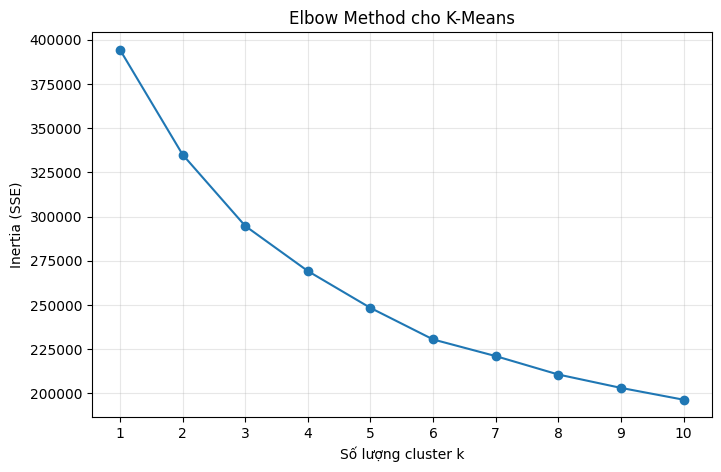

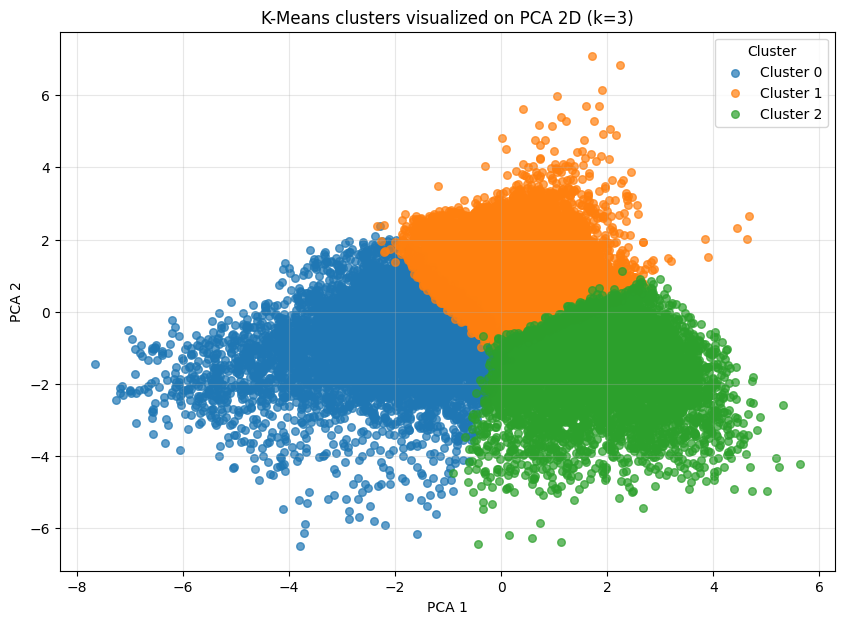



CLUSTER CENTROIDS (original scale):
             co    no2      o3    pm10   pm25    so2  clouds  precipitation  pressure  relative_humidity  temperature  uv_index  wind_speed
cluster                                                                                                                                    
0        350.60  43.87   41.79  120.40  86.52  80.83   78.56           0.08   1017.39              76.18        19.17      0.73        1.56
1        413.27  24.35   41.65   45.74  33.77  47.40   72.74           0.40   1007.12              85.84        25.92      0.64        1.78
2        183.41  13.36  111.73   53.72  40.45  73.59   57.70           0.12   1007.42              61.23        29.77      3.57        2.05


CLUSTER PROFILE REPORT:
            co                                 no2                               o3                              pm10                               pm25                              so2                            clouds                 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1. LOAD VÀ LÀM SẠCH DỮ LIỆU
try:
    df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv', low_memory=False, on_bad_lines='skip')
except Exception as e:
    print(f"Error reading cleaned file: {e}")
    files = ['../data_raw/2022.csv', '../data_raw/2023.csv', '../data_raw/2024.csv', '../data_raw/2025.csv']
    df_list = []
    for f in files:
        try:
            df_list.append(pd.read_csv(f, low_memory=False, on_bad_lines='skip'))
        except:
            pass
    df = pd.concat(df_list, ignore_index=True)

df['date'] = pd.to_datetime(df['date'], errors='coerce')
SEASON_MAP = {0: 'Đông', 1: 'Xuân', 2: 'Hè', 3: 'Thu'}

# 2. CHUẨN BỊ FEATURE VÀ CHUẨN HÓA
feature_cols = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 
                'precipitation', 'pressure', 'relative_humidity', 
                'temperature', 'uv_index', 'wind_speed']

# Kiểm tra xem các cột có tồn tại trong dữ liệu thực tế không
feature_cols = [c for c in feature_cols if c in df.columns]

# ĐÃ BỎ .dropna() - Giữ nguyên vẹn index của df gốc
X = df[feature_cols]

print(f"Số dòng dữ liệu để clustering: {len(X)}")
print(f"Các feature sử dụng: {feature_cols}\n")

scaler = StandardScaler()
X_scaled_std = scaler.fit_transform(X)

# 3. ELBOW METHOD (TÌM K TỐI ƯU)
inertia = []
ks = list(range(1, 11))
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_std)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(ks, inertia, marker='o')
plt.xticks(ks)
plt.xlabel('Số lượng cluster k')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method cho K-Means')
plt.grid(alpha=0.3)
plt.show()

print('\n' + '='*80 + '\n')

# 4. K-MEANS CLUSTERING VỚI K=3
k_opt = 3
km = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled_std)

# 5. TRỰC QUAN HÓA BẰNG PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_std)

plt.figure(figsize=(10, 7))
palette = sns.color_palette('tab10', n_colors=k_opt)
for cluster_id in sorted(np.unique(labels)):
    mask = labels == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[palette[cluster_id]], s=30, alpha=0.7, label=f'Cluster {cluster_id}')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title(f'K-Means clusters visualized on PCA 2D (k={k_opt})')
plt.legend(title='Cluster')
plt.grid(alpha=0.3)
plt.show()

print('\n' + '='*80 + '\n')

# 6. BÁO CÁO ĐẶC TRƯNG CÁC CỤM (CLUSTER PROFILE)
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=X.columns
)
cluster_centers.index.name = 'cluster'
print('CLUSTER CENTROIDS (original scale):')
print(cluster_centers.round(2))

print('\n' + '='*80 + '\n')

# Vì không drop dòng nào nên sao chép trực tiếp từ df gốc cực kỳ an toàn
clustered_df = df.copy()
clustered_df['cluster'] = labels

profile_report = clustered_df.groupby('cluster')[feature_cols].agg(['count', 'mean', 'std', 'min', 'max'])
print('CLUSTER PROFILE REPORT:')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 200):
    print(profile_report.round(2).to_string())

print('\n' + '='*80 + '\n')

# 7. ĐÁNH GIÁ MÔ HÌNH (TÍNH SILHOUETTE SCORE)
print('ĐÁNH GIÁ MÔ HÌNH PHÂN CỤM:')
sil_score = silhouette_score(X_scaled_std, labels, sample_size=5000, random_state=42)
print(f'✨ Silhouette Score (on 5000 sample): {sil_score:.3f} (higher is better, range: [-1, 1])')

print('\n' + '='*80 + '\n')

# 8. PHÂN TÍCH ĐẶC TRƯNG THỜI GIAN VÀ AQI
if 'hour' not in clustered_df.columns and 'date' in clustered_df.columns:
    clustered_df['hour'] = clustered_df['date'].dt.hour
if 'month' not in clustered_df.columns and 'date' in clustered_df.columns:
    clustered_df['month'] = clustered_df['date'].dt.month

if 'season' in clustered_df.columns:
    clustered_df['season_name'] = clustered_df['season'].map(SEASON_MAP)
elif 'month' in clustered_df.columns:
    clustered_df['season_name'] = pd.cut(
        clustered_df['month'],
        bins=[0, 3, 6, 9, 12],
        labels=['Đông', 'Xuân', 'Hè', 'Thu'],
        right=True
    )

print('CLUSTER SIZE:')
print(clustered_df['cluster'].value_counts().sort_index())
print()

if 'aqi' in clustered_df.columns:
    print('MEAN AQI BY CLUSTER:')
    print(clustered_df.groupby('cluster')['aqi'].agg(['mean', 'std', 'min', 'max']).round(2))
    print()

# Cấu hình hiển thị full bảng không bị bẻ dòng khi in 24 giờ
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 300)

if 'season_name' in clustered_df.columns:
    print('CLUSTER DISTRIBUTION BY SEASON (Full Table):')
    season_table = clustered_df.groupby(['cluster', 'season_name']).size().unstack(fill_value=0)
    print(season_table.to_string())
    print()

if 'hour' in clustered_df.columns:
    print('CLUSTER DISTRIBUTION BY HOUR (Full 24 Hours):')
    hour_counts = clustered_df.groupby(['cluster', 'hour']).size().unstack(fill_value=0)
    print(hour_counts.to_string())
    print()
    
    print('Hour with most members in each cluster:')
    top_hours = hour_counts.idxmax(axis=1)
    print(top_hours.to_string())
    print()

if 'aqi' in clustered_df.columns:
    print('CLUSTERS RANKED BY MEAN AQI:')
    aqi_cluster = clustered_df.groupby('cluster')['aqi'].mean().sort_values(ascending=False)
    print(aqi_cluster.round(2).to_string())